<a href="https://colab.research.google.com/github/salphonseds/llm-from-scratch/blob/main/notebooks/03_Positional_Encodings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell #1: Setup and Imports
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)

# Hyperparameters (same as before)
d_model = 512      # Model dimension
max_seq_len = 100  # Maximum sequence length we'll support
batch_size = 2     # For testing

print(f"\nHyperparameters:")
print(f"d_model: {d_model}")
print(f"max_seq_len: {max_seq_len}")
print(f"batch_size: {batch_size}")

Using device: cuda

Hyperparameters:
d_model: 512
max_seq_len: 100
batch_size: 2


In [ ]:
# Cell #2: Sinusoidal Positional Encoding Implementation
def get_sinusoidal_positional_encoding(max_seq_len, d_model):
    """
    Create sinusoidal positional encodings.

    Args:
        max_seq_len: Maximum sequence length
        d_model: Model dimension (must be even)

    Returns:
        pe: Positional encoding matrix [max_seq_len, d_model]
    """
    # Initialize positional encoding matrix
    pe = torch.zeros(max_seq_len, d_model)

    # Create position indices [0, 1, 2, ..., max_seq_len-1]
    # Shape: [max_seq_len, 1]
    position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)

    # Create dimension indices [0, 2, 4, ..., d_model-2]
    # We use arange(0, d_model, 2) to get even indices
    # Shape: [d_model/2]
    div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                         (-math.log(10000.0) / d_model))

    # Apply sine to even dimensions (0, 2, 4, ...)
    pe[:, 0::2] = torch.sin(position * div_term)

    # Apply cosine to odd dimensions (1, 3, 5, ...)
    pe[:, 1::2] = torch.cos(position * div_term)

    return pe

# Generate positional encodings
pe = get_sinusoidal_positional_encoding(max_seq_len, d_model)

print(f"Positional Encoding shape: {pe.shape}")
print(f"\nFirst position (pos=0) - first 10 dimensions:")
print(pe[0, :10])
print(f"\nSecond position (pos=1) - first 10 dimensions:")
print(pe[1, :10])
print(f"\nValue range: [{pe.min():.3f}, {pe.max():.3f}]")

Positional Encoding shape: torch.Size([100, 512])

First position (pos=0) - first 10 dimensions:
tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])

Second position (pos=1) - first 10 dimensions:
tensor([0.8415, 0.5403, 0.8219, 0.5697, 0.8020, 0.5974, 0.7819, 0.6234, 0.7617,
        0.6479])

Value range: [-1.000, 1.000]


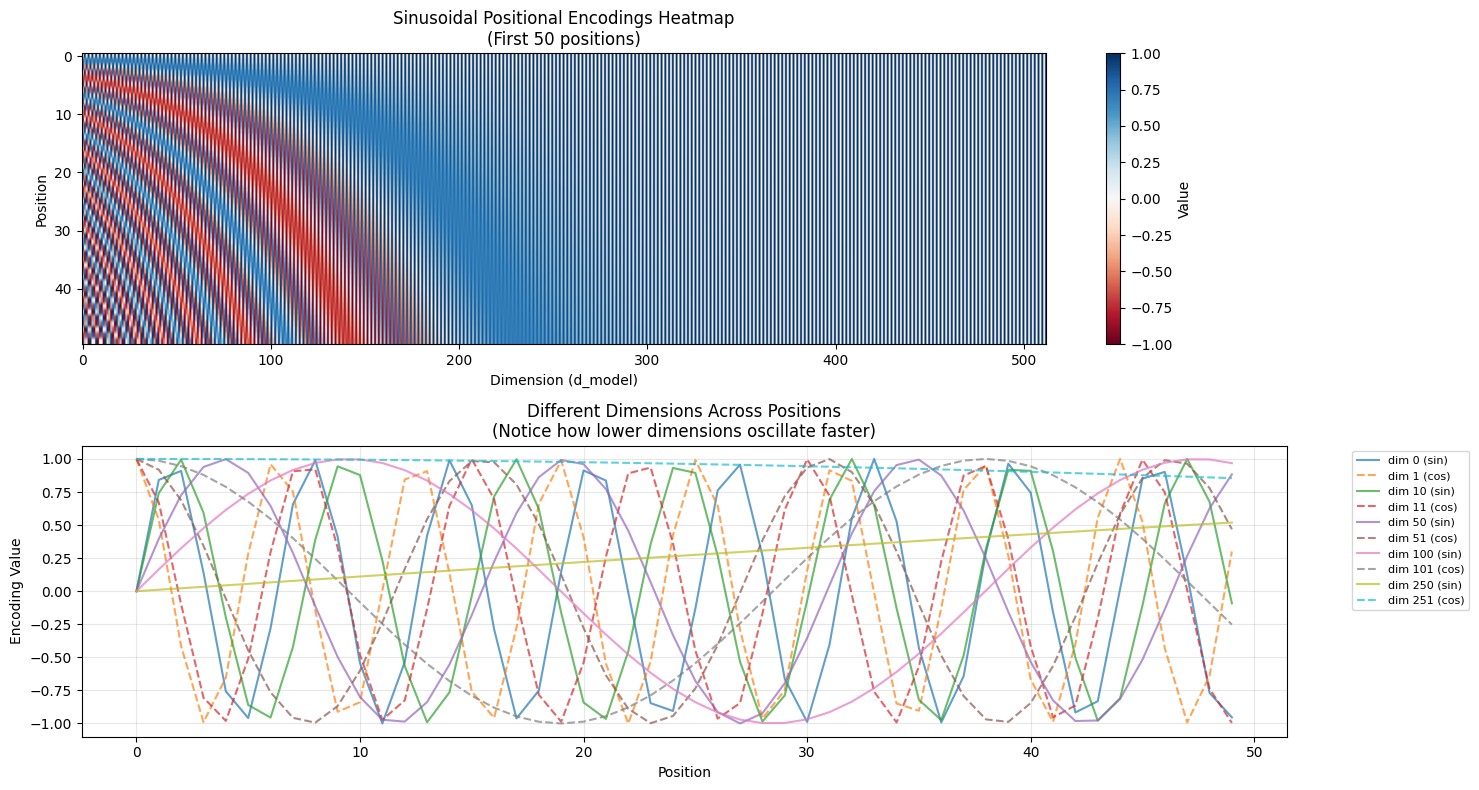

🎨 Visualization complete!

Key observations to notice:
1. Heatmap shows vertical stripes → same pattern across positions
2. Low dimensions (0, 1, 10, 11) oscillate FAST → fine-grained position info
3. High dimensions (250, 251) oscillate SLOW → coarse position info
4. Sin/cos pairs are phase-shifted (solid vs dashed lines)


In [ ]:
# Cell #3: Visualize Positional Encodings
plt.figure(figsize=(15, 8))

# Plot 1: Heatmap of positional encodings
plt.subplot(2, 1, 1)
plt.imshow(pe[:50, :].numpy(), cmap='RdBu', aspect='auto')
plt.colorbar(label='Value')
plt.xlabel('Dimension (d_model)')
plt.ylabel('Position')
plt.title('Sinusoidal Positional Encodings Heatmap\n(First 50 positions)')
plt.tight_layout()

# Plot 2: Selected dimensions across positions
plt.subplot(2, 1, 2)
positions = torch.arange(0, 50)

# Plot a few dimensions to see different frequencies
dims_to_plot = [0, 1, 10, 11, 50, 51, 100, 101, 250, 251]
for dim in dims_to_plot:
    if dim % 2 == 0:
        label = f'dim {dim} (sin)'
        linestyle = '-'
    else:
        label = f'dim {dim} (cos)'
        linestyle = '--'
    plt.plot(positions, pe[:50, dim].numpy(), label=label, linestyle=linestyle, alpha=0.7)

plt.xlabel('Position')
plt.ylabel('Encoding Value')
plt.title('Different Dimensions Across Positions\n(Notice how lower dimensions oscillate faster)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

print("🎨 Visualization complete!")
print("\nKey observations to notice:")
print("1. Heatmap shows vertical stripes → same pattern across positions")
print("2. Low dimensions (0, 1, 10, 11) oscillate FAST → fine-grained position info")
print("3. High dimensions (250, 251) oscillate SLOW → coarse position info")
print("4. Sin/cos pairs are phase-shifted (solid vs dashed lines)")

In [ ]:
# Cell #4: PositionalEncoding Class
class PositionalEncoding(nn.Module):
    """
    Adds sinusoidal positional encodings to input embeddings.
    """
    def __init__(self, d_model, max_seq_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                           (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension: [1, max_seq_len, d_model]
        pe = pe.unsqueeze(0)

        # Register as buffer (not a parameter - won't be trained)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Input embeddings [batch_size, seq_len, d_model]
        Returns:
            x + positional encoding [batch_size, seq_len, d_model]
        """
        # Add positional encoding to input
        # self.pe[:, :x.size(1)] selects only the positions we need
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# Create the module
pos_encoding = PositionalEncoding(d_model=d_model, max_seq_len=max_seq_len)

# Test it with sample embeddings
seq_len = 10
sample_embeddings = torch.randn(batch_size, seq_len, d_model)

print(f"Input shape: {sample_embeddings.shape}")
output = pos_encoding(sample_embeddings)
print(f"Output shape: {output.shape}")
print(f"\nPositional encoding successfully added! ✅")

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])

Positional encoding successfully added! ✅


In [ ]:
# Cell #5: Learned Positional Embeddings
class LearnedPositionalEmbedding(nn.Module):
    """
    Learned positional embeddings (used in GPT-2, GPT-3).
    These are trainable parameters, not fixed functions.
    """
    def __init__(self, max_seq_len, d_model, dropout=0.1):
        super().__init__()
        # Embedding table: [max_seq_len, d_model]
        # Each position learns its own d_model-dimensional vector
        self.position_embeddings = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        """
        Args:
            x: Input embeddings [batch_size, seq_len, d_model]
        Returns:
            x + learned positional embeddings [batch_size, seq_len, d_model]
        """
        batch_size, seq_len, d_model = x.shape

        # Create position indices: [0, 1, 2, ..., seq_len-1]
        positions = torch.arange(0, seq_len, device=x.device)

        # Get position embeddings: [seq_len, d_model]
        pos_emb = self.position_embeddings(positions)

        # Add positional embeddings (broadcasting handles batch dimension)
        x = x + pos_emb
        return self.dropout(x)

# Create the module
learned_pos_embedding = LearnedPositionalEmbedding(
    max_seq_len=max_seq_len,
    d_model=d_model
)

# Test it
sample_embeddings = torch.randn(batch_size, seq_len, d_model)
print(f"Input shape: {sample_embeddings.shape}")
output = learned_pos_embedding(sample_embeddings)
print(f"Output shape: {output.shape}")

# Check number of parameters
num_params = sum(p.numel() for p in learned_pos_embedding.parameters())
print(f"\nNumber of trainable parameters: {num_params:,}")
print(f"(max_seq_len × d_model = {max_seq_len} × {d_model} = {max_seq_len * d_model:,})")
print(f"\n✅ Learned positional embeddings created!")

Input shape: torch.Size([2, 10, 512])
Output shape: torch.Size([2, 10, 512])

Number of trainable parameters: 51,200
(max_seq_len × d_model = 100 × 512 = 51,200)

✅ Learned positional embeddings created!


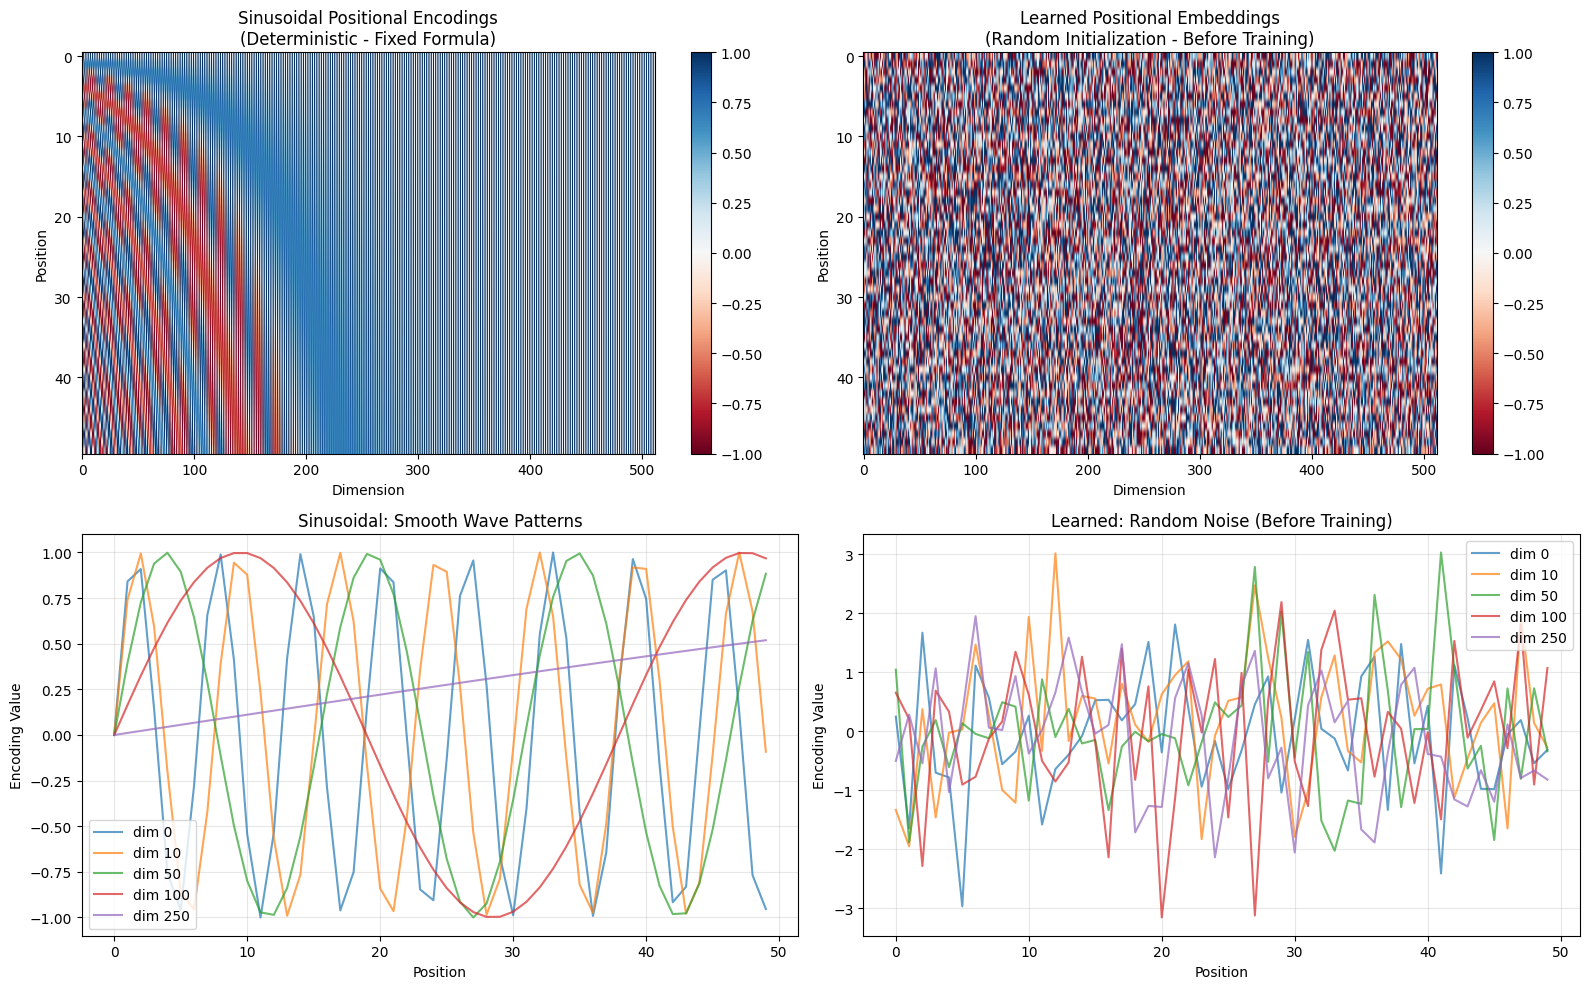

🎨 Comparison complete!

Key Differences:
✅ Sinusoidal: Smooth, periodic patterns (sine/cosine waves)
✅ Learned: Random noise initially, would become structured after training


In [ ]:
# Cell #6: Visualize Sinusoidal vs Learned Encodings
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Get sinusoidal encodings
sinusoidal_pe = pos_encoding.pe.squeeze(0)[:50, :].detach().numpy()

# Get learned embeddings (before training - random initialization)
learned_pe = learned_pos_embedding.position_embeddings.weight[:50, :].detach().numpy()

# Plot 1: Sinusoidal heatmap
im1 = axes[0, 0].imshow(sinusoidal_pe, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0, 0].set_xlabel('Dimension')
axes[0, 0].set_ylabel('Position')
axes[0, 0].set_title('Sinusoidal Positional Encodings\n(Deterministic - Fixed Formula)')
plt.colorbar(im1, ax=axes[0, 0])

# Plot 2: Learned heatmap
im2 = axes[0, 1].imshow(learned_pe, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0, 1].set_xlabel('Dimension')
axes[0, 1].set_ylabel('Position')
axes[0, 1].set_title('Learned Positional Embeddings\n(Random Initialization - Before Training)')
plt.colorbar(im2, ax=axes[0, 1])

# Plot 3: Sinusoidal - selected dimensions
positions = np.arange(50)
for dim in [0, 10, 50, 100, 250]:
    axes[1, 0].plot(positions, sinusoidal_pe[:, dim], label=f'dim {dim}', alpha=0.7)
axes[1, 0].set_xlabel('Position')
axes[1, 0].set_ylabel('Encoding Value')
axes[1, 0].set_title('Sinusoidal: Smooth Wave Patterns')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Learned - selected dimensions
for dim in [0, 10, 50, 100, 250]:
    axes[1, 1].plot(positions, learned_pe[:, dim], label=f'dim {dim}', alpha=0.7)
axes[1, 1].set_xlabel('Position')
axes[1, 1].set_ylabel('Encoding Value')
axes[1, 1].set_title('Learned: Random Noise (Before Training)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎨 Comparison complete!")
print("\nKey Differences:")
print("✅ Sinusoidal: Smooth, periodic patterns (sine/cosine waves)")
print("✅ Learned: Random noise initially, would become structured after training")

In [ ]:
# Cell #7: Token + Positional Embedding Pipeline
class TokenPositionalEmbedding(nn.Module):
    """
    Combines token embeddings with positional encodings.
    This is the INPUT layer for transformer models.
    """
    def __init__(self, vocab_size, d_model, max_seq_len, dropout=0.1, use_learned_pos=False):
        super().__init__()

        # Token embeddings: convert token IDs to vectors
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Positional encodings: choose sinusoidal or learned
        if use_learned_pos:
            self.pos_encoding = LearnedPositionalEmbedding(max_seq_len, d_model, dropout)
            print("Using LEARNED positional embeddings")
        else:
            self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)
            print("Using SINUSOIDAL positional encodings")

        self.d_model = d_model

    def forward(self, token_ids):
        """
        Args:
            token_ids: Token indices [batch_size, seq_len]
        Returns:
            embeddings: Token + positional embeddings [batch_size, seq_len, d_model]
        """
        # Step 1: Convert token IDs to embeddings
        token_emb = self.token_embedding(token_ids)  # [batch, seq_len, d_model]

        # Step 2: Scale by sqrt(d_model) (mentioned in original paper)
        # This helps balance the magnitude of embeddings and positional encodings
        token_emb = token_emb * math.sqrt(self.d_model)

        # Step 3: Add positional encodings
        output = self.pos_encoding(token_emb)

        return output

# Test with both approaches
vocab_size = 1000  # Small vocabulary for testing
seq_len = 10

# Create sample token IDs
sample_tokens = torch.randint(0, vocab_size, (batch_size, seq_len))
print(f"Sample token IDs shape: {sample_tokens.shape}")
print(f"Sample tokens (first sequence): {sample_tokens[0].tolist()}\n")

# Test with sinusoidal
print("=" * 60)
embedding_sinusoidal = TokenPositionalEmbedding(
    vocab_size=vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    use_learned_pos=False
)
output_sin = embedding_sinusoidal(sample_tokens)
print(f"Output shape: {output_sin.shape}")

print("\n" + "=" * 60)
# Test with learned
embedding_learned = TokenPositionalEmbedding(
    vocab_size=vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    use_learned_pos=True
)
output_learned = embedding_learned(sample_tokens)
print(f"Output shape: {output_learned.shape}")

print("\n" + "=" * 60)
print("✅ Complete embedding pipeline working!")
print(f"\nPipeline: Token IDs → Token Embeddings → Scale by √d_model → Add Position → Output")

Sample token IDs shape: torch.Size([2, 10])
Sample tokens (first sequence): [565, 809, 873, 450, 639, 29, 629, 426, 765, 457]

Using SINUSOIDAL positional encodings
Output shape: torch.Size([2, 10, 512])

Using LEARNED positional embeddings
Output shape: torch.Size([2, 10, 512])

✅ Complete embedding pipeline working!

Pipeline: Token IDs → Token Embeddings → Scale by √d_model → Add Position → Output


In [ ]:
# Cell #8: End-to-End Pipeline with Transformer Blocks
# First, let's recreate TransformerBlock from Day 3 (simplified version)

class TransformerBlock(nn.Module):
    """Complete Transformer Block from Day 3"""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # Multi-Head Attention
        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True  # Important: batch dimension first
        )

        # Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        # Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Sub-layer 1: Multi-Head Attention + Add & Norm
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + self.dropout1(attn_output))

        # Sub-layer 2: Feed-Forward + Add & Norm
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_output))

        return x

# Complete end-to-end model
class SimpleTransformer(nn.Module):
    """
    Complete Transformer: Embeddings → Transformer Blocks → Output
    """
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers,
                 max_seq_len, dropout=0.1, use_learned_pos=False):
        super().__init__()

        # Input: Token + Positional Embeddings
        self.embedding = TokenPositionalEmbedding(
            vocab_size, d_model, max_seq_len, dropout, use_learned_pos
        )

        # Stack of Transformer Blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        # Output projection (for language modeling)
        self.output_projection = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):
        # Step 1: Embed tokens + add positions
        x = self.embedding(token_ids)  # [batch, seq_len, d_model]

        # Step 2: Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Step 3: Project to vocabulary
        logits = self.output_projection(x)  # [batch, seq_len, vocab_size]

        return logits

# Create the model
print("Creating complete transformer model...\n")
model = SimpleTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=8,
    d_ff=2048,
    num_layers=3,  # 3 transformer blocks
    max_seq_len=max_seq_len,
    use_learned_pos=False  # Using sinusoidal
).to(device)

# Test with sample tokens
sample_tokens = sample_tokens.to(device)
print(f"Input token IDs shape: {sample_tokens.shape}")

# Forward pass
with torch.no_grad():
    output_logits = model(sample_tokens)

print(f"Output logits shape: {output_logits.shape}")
print(f"\n✅ Complete pipeline working!")
print(f"\nFlow: Token IDs [2, 10] → Embeddings [2, 10, 512] → ")
print(f"      3 Transformer Blocks → Logits [2, 10, 1000]")

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Creating complete transformer model...

Using SINUSOIDAL positional encodings
Input token IDs shape: torch.Size([2, 10])
Output logits shape: torch.Size([2, 10, 1000])

✅ Complete pipeline working!

Flow: Token IDs [2, 10] → Embeddings [2, 10, 512] → 
      3 Transformer Blocks → Logits [2, 10, 1000]

Total parameters: 10,482,152


In [ ]:
# Cell #9: Parameter Breakdown
print("Parameter Breakdown:\n")
print("=" * 70)

for name, param in model.named_parameters():
    print(f"{name:50s} {param.shape} = {param.numel():,} params")

print("=" * 70)

# Calculate by component
token_emb_params = vocab_size * d_model
pos_emb_params = 0  # Sinusoidal (no params)
transformer_params = sum(p.numel() for block in model.transformer_blocks for p in block.parameters())
output_proj_params = d_model * vocab_size + vocab_size  # weights + bias

print(f"\nBy Component:")
print(f"  Token Embedding:        {token_emb_params:,} params")
print(f"  Positional Encoding:    {pos_emb_params:,} params (sinusoidal - fixed)")
print(f"  3 Transformer Blocks:   {transformer_params:,} params")
print(f"  Output Projection:      {output_proj_params:,} params")
print(f"  {'─' * 50}")
print(f"  TOTAL:                  {total_params:,} params")

# Test gradient flow
print("\n" + "=" * 70)
print("Testing gradient flow...\n")

# Create dummy target
target = torch.randint(0, vocab_size, (batch_size, seq_len)).to(device)

# Forward pass
logits = model(sample_tokens)

# Compute loss (cross-entropy for language modeling)
loss = nn.CrossEntropyLoss()(
    logits.view(-1, vocab_size),  # Flatten: [batch*seq_len, vocab_size]
    target.view(-1)                # Flatten: [batch*seq_len]
)

# Backward pass
loss.backward()

print(f"Loss: {loss.item():.4f}")
print(f"✅ Gradients computed successfully!")
print(f"\nSample gradients:")
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"  {name[:50]:50s} grad norm: {param.grad.norm().item():.4f}")
        break  # Just show first one

print("\n✅ Complete pipeline with gradient flow verified!")

Parameter Breakdown:

embedding.token_embedding.weight                   torch.Size([1000, 512]) = 512,000 params
transformer_blocks.0.attention.in_proj_weight      torch.Size([1536, 512]) = 786,432 params
transformer_blocks.0.attention.in_proj_bias        torch.Size([1536]) = 1,536 params
transformer_blocks.0.attention.out_proj.weight     torch.Size([512, 512]) = 262,144 params
transformer_blocks.0.attention.out_proj.bias       torch.Size([512]) = 512 params
transformer_blocks.0.ffn.0.weight                  torch.Size([2048, 512]) = 1,048,576 params
transformer_blocks.0.ffn.0.bias                    torch.Size([2048]) = 2,048 params
transformer_blocks.0.ffn.3.weight                  torch.Size([512, 2048]) = 1,048,576 params
transformer_blocks.0.ffn.3.bias                    torch.Size([512]) = 512 params
transformer_blocks.0.norm1.weight                  torch.Size([512]) = 512 params
transformer_blocks.0.norm1.bias                    torch.Size([512]) = 512 params
transformer_block

In [ ]:
# Cell #10: Architecture Summary Visualization
print("🏗️  COMPLETE TRANSFORMER ARCHITECTURE")
print("=" * 70)
print()
print("INPUT: Token IDs [batch_size, seq_len]")
print("  │")
print("  ├─→ Token Embedding: vocab_size → d_model")
print("  │   └─→ [batch, seq_len, d_model]")
print("  │")
print("  ├─→ Scale by √d_model")
print("  │")
print("  ├─→ Add Positional Encoding (sinusoidal or learned)")
print("  │   └─→ [batch, seq_len, d_model]")
print("  │")
print("  ▼")
print("TRANSFORMER BLOCKS (×3):")
print("  │")
print("  ├─→ Block 1:")
print("  │   ├─ Multi-Head Attention (8 heads)")
print("  │   ├─ Add & Norm")
print("  │   ├─ Feed-Forward (512→2048→512)")
print("  │   └─ Add & Norm")
print("  │")
print("  ├─→ Block 2: [same structure]")
print("  │")
print("  ├─→ Block 3: [same structure]")
print("  │")
print("  ▼")
print("OUTPUT PROJECTION:")
print("  │")
print("  └─→ Linear: d_model → vocab_size")
print("      └─→ [batch, seq_len, vocab_size]")
print()
print("=" * 70)
print()
print("📊 PARAMETER COUNT:")
print(f"  • Token Embedding:      {512000:>10,} params")
print(f"  • Positional Encoding:  {0:>10,} params (sinusoidal)")
print(f"  • Transformer Blocks:   {9457152:>10,} params (90%)")
print(f"  • Output Projection:    {513000:>10,} params")
print(f"  {'─' * 45}")
print(f"  • TOTAL:                {10482152:>10,} params")
print()
print("=" * 70)
print("✅ Day 4-5 COMPLETE: Positional Encodings Mastered!")

🏗️  COMPLETE TRANSFORMER ARCHITECTURE

INPUT: Token IDs [batch_size, seq_len]
  │
  ├─→ Token Embedding: vocab_size → d_model
  │   └─→ [batch, seq_len, d_model]
  │
  ├─→ Scale by √d_model
  │
  ├─→ Add Positional Encoding (sinusoidal or learned)
  │   └─→ [batch, seq_len, d_model]
  │
  ▼
TRANSFORMER BLOCKS (×3):
  │
  ├─→ Block 1:
  │   ├─ Multi-Head Attention (8 heads)
  │   ├─ Add & Norm
  │   ├─ Feed-Forward (512→2048→512)
  │   └─ Add & Norm
  │
  ├─→ Block 2: [same structure]
  │
  ├─→ Block 3: [same structure]
  │
  ▼
OUTPUT PROJECTION:
  │
  └─→ Linear: d_model → vocab_size
      └─→ [batch, seq_len, vocab_size]


📊 PARAMETER COUNT:
  • Token Embedding:         512,000 params
  • Positional Encoding:           0 params (sinusoidal)
  • Transformer Blocks:    9,457,152 params (90%)
  • Output Projection:       513,000 params
  ─────────────────────────────────────────────
  • TOTAL:                10,482,152 params

✅ Day 4-5 COMPLETE: Positional Encodings Mastered!
